# Interp methods survey & first-method choice

**2026-09-01, interp-week block 1.** A *working* notebook, not a claims notebook
(no C-numbers; claims stay in `review/`). Three jobs:

1. **Catalog the proven methods** of 2026 interp with a minimal runnable example
   of each observational one, so the mechanics are in fingers, not just in notes.
2. **Settle "is Thought Anchors in scope?"** and log the new near-neighbor it
   surfaced (Sycophantic Anchors, Jan 2026).
3. **Fix the roadmap**: proven methods on the critical path, experimental ones
   (MVAR/VARX, turn-resampling) as numbered future items — and name the **first
   method** to learn and apply this week.

Builds on `INTERP-METHODS.md` (the ladder of record, L1–L7),
`refs/mvar-dynamics-and-methods-map.md` (§4 maturity map), and
`refs/deepdive-interp.md`. Demos run on **synthetic data shaped like our real
cache will be** (`resid[trial, turn, d]` at the end-of-turn token) — no GPU, no
model, so every cell runs on this box in seconds. The point of each demo is the
*reading*: what result pattern would mean what, decided before real data exists.


## 1. The proven core, September 2026

Condensed from `refs/mvar-dynamics-and-methods-map.md` §4 (calibrated against
Open Problems in MI, arXiv 2501.16496; Rai et al. practical review, 2407.02646;
AxBench, 2501.17148) with two additions from today's verification pass
(rows marked ★):

| Method | Status 2026 | Ladder rung | Demo below |
|---|---|---|---|
| Linear/ridge/logistic probes | **Proven** workhorse; near-best concept detection in AxBench | L1 | §2A |
| Difference-in-means direction | **Proven**; AxBench best-in-class detection; refusal-paper recipe | L2 | §2B |
| PCA / trajectory geometry | **Proven as description** (population-dynamics language) | L3 | §2C |
| Activation addition (steering) | **Proven with caveats** — causal, but prompting beats it for *control* (AxBench) | L5 | §2D sketch |
| Directional ablation | **Proven** (refusal recipe: project direction out everywhere) | L5 | §2D sketch |
| Activation patching | **Proven** field workhorse; expensive for us | L7 stretch | — |
| Logit/tuned lens (2303.08112) | Cheap proven-as-heuristic diagnostic | direction check | — |
| ★ Counterfactual resampling over trace units (Thought Anchors, 2506.19143, NeurIPS 2025) | **Proven for CoT sentences**; black-box | not on ladder → roadmap R2 | §3 toy |
| SAEs | **Experimental** — interpret, don't discover (canonical-units/absorption critiques; GDM negative results) | L6, gated | — |
| ★ Probe *ensembles* / stability | Not a method family — robustness **hygiene** for L1–L2 | reporting practice | §4 |
| MVAR / Granger across turns | Proven in neuro, ~absent in LLM interp | roadmap R1, off critical path | — |

The 2026 headline is consolidation, not new machinery: probes + mean-difference
directions + causal interventions are the load-bearing trio everywhere
(e.g. Assistant Axis, Jan 2026, is diff-in-means + steering at scale), and the
SAE-skepticism cluster pushed discovery claims back toward exactly these
simple tools. Our L1–L3+L5 plan *is* the 2026 mainstream — good.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score, KFold
from sklearn.decomposition import PCA

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 96


## 2. Synthetic testbed — the shape of our future cache

We mimic `resid[trial, turn, d]`: one end-of-turn residual vector per trial per
round, single layer, `d`=64 (real: `n_layers × d_model`, same math per layer).
Two worlds, matching the pre-registered L1 readings in `INTERP-METHODS.md` §4:

- **Continuous world**: a drift *direction* whose magnitude grows with round
  (front-loaded, like the behavioral curves) — the "dial" hypothesis.
- **Bimodal world**: the same direction but only two magnitudes, committed vs
  conceded, with the flip round varying per trial — the "switch" hypothesis.

Both worlds decode round-1-vs-8 perfectly; finding what *does* separate them is
the point of demo 2A — and the answer surprised us (see its header).


In [2]:
D, N_TRIALS, N_TURNS = 64, 72, 8          # 72 trials/model, 8 rounds — real sizes
drift_dir = rng.normal(size=D); drift_dir /= np.linalg.norm(drift_dir)
base = rng.normal(size=D) * 0.5

def make_world(kind, noise=1.0):
    """resid[trial, turn, d] with drift along one direction."""
    X = np.zeros((N_TRIALS, N_TURNS, D))
    for i in range(N_TRIALS):
        if kind == "continuous":                       # front-loaded saturating dial
            mag = 5.0 * (1 - np.exp(-np.arange(N_TURNS) / 2.0))
        elif kind == "bimodal":                        # switch flips at a per-trial round
            flip = rng.integers(2, 7)
            mag = np.where(np.arange(N_TURNS) >= flip, 5.0, 0.0)
        X[i] = base + mag[:, None] * drift_dir + rng.normal(size=(N_TURNS, D)) * noise
    return X

worlds = {k: make_world(k) for k in ("continuous", "bimodal")}
for k, X in worlds.items():
    print(f"{k:11s} resid[trial, turn, d] = {X.shape}, {X.nbytes/1e6:.1f} MB")


continuous  resid[trial, turn, d] = (72, 8, 64), 0.3 MB
bimodal     resid[trial, turn, d] = (72, 8, 64), 0.3 MB


### 2A. L1 — linear probe: classify, regress — and the reading this demo *corrected*

Method (real-data version identical, plus per-layer loop):
classify round 1 vs round 8 with logistic regression, 5-fold CV;
**controls**: shuffled labels (must fall to chance). Then ridge-regress the
*round number* from the residual.

**Finding from building this demo — a revision to `INTERP-METHODS.md` §2's L1
reading.** The planned reading was "classify works but regression doesn't →
bimodal". The toy falsifies it: regression R² barely separates the worlds (0.53 vs 0.40
here; at lower drift SNR the gap vanishes entirely — both hit 0.29 at magnitude
3), because saturating continuous drift and a trial-varying flip round both
decouple round number from state. The reliable dial-vs-switch
discriminator is the **per-round distribution of projections onto the drift
axis**: a dial shifts one unimodal cloud; a switch moves mass between two fixed
modes (transiently large variance + bimodality at middle rounds). Numeric
version: per-round ΔBIC of a 2- vs 1-component Gaussian mixture on the
projections. Carry this into the real L1: report classify acc, regression R²,
*and* the mixture check — regression alone can't be trusted to read the geometry.


continuous   classify acc=0.98 (shuffled 0.52)   round-regression R^2=0.53   max per-round mixture ΔBIC=-1
bimodal      classify acc=0.99 (shuffled 0.50)   round-regression R^2=0.40   max per-round mixture ΔBIC=37


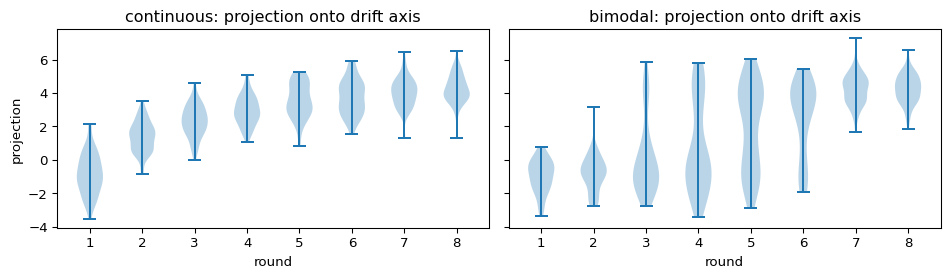


Reading: classification is identical and regression R^2 barely differs; only the projection distributions (violins / ΔBIC) tell a dial from a switch. If the real data is a switch, the 0-10 self-report dial is *shaped wrong* for the internal object.


In [3]:
from sklearn.mixture import GaussianMixture

def probe_report(X, name):
    r1, r8 = X[:, 0, :], X[:, 7, :]
    Xc = np.vstack([r1, r8]); yc = np.r_[np.zeros(N_TRIALS), np.ones(N_TRIALS)]
    acc = cross_val_score(LogisticRegression(max_iter=2000), Xc, yc, cv=5).mean()
    y_shuf = rng.permutation(yc)                      # control: shuffled labels
    acc_shuf = cross_val_score(LogisticRegression(max_iter=2000), Xc, y_shuf, cv=5).mean()

    Xr = X.reshape(-1, D)                             # regression on round number
    yr = np.repeat(np.arange(N_TURNS)[None, :], N_TRIALS, axis=0).ravel()
    r2 = cross_val_score(Ridge(alpha=10.0), Xr, yr, cv=KFold(5, shuffle=True, random_state=0),
                         scoring="r2").mean()

    dm = X[:, 7].mean(0) - X[:, 0].mean(0); dm /= np.linalg.norm(dm)
    proj = X @ dm                                     # [trial, turn] projections
    dbic = []                                         # mixture check per round
    for t in range(N_TURNS):
        p = proj[:, t:t+1]
        dbic.append(GaussianMixture(1, random_state=0).fit(p).bic(p)
                    - GaussianMixture(2, random_state=0).fit(p).bic(p))
    print(f"{name:11s}  classify acc={acc:.2f} (shuffled {acc_shuf:.2f})   "
          f"round-regression R^2={r2:.2f}   max per-round mixture ΔBIC={max(dbic):.0f}")
    return proj, max(dbic)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
results = {}
for ax, (k, X) in zip(axes, worlds.items()):
    proj, dbic = probe_report(X, k); results[k] = dbic
    ax.violinplot([proj[:, t] for t in range(N_TURNS)], positions=np.arange(1, 9))
    ax.set_title(f"{k}: projection onto drift axis"); ax.set_xlabel("round")
axes[0].set_ylabel("projection")
plt.tight_layout(); plt.show()

assert results["bimodal"] > 20 > results["continuous"], "mixture check should separate the worlds"
print("\nReading: classification is identical and regression R^2 barely differs; only the "
      "projection distributions (violins / ΔBIC) tell a dial from a switch. If the real "
      "data is a switch, the 0-10 self-report dial is *shaped wrong* for the internal object.")


### 2B. L2 — one direction or many? diff-in-means vs trained probe

Diff-in-means (`mean(round8) − mean(round1)`) is the AxBench-winning detector
and needs no training. If it agrees with the trained probe's coefficient vector
(high cosine) and PC1 of the per-round means dominates, the story is a *single
linear axis* — the refusal-paper shape.


In [4]:
for k, X in worlds.items():
    dm = X[:, 7].mean(0) - X[:, 0].mean(0); dm /= np.linalg.norm(dm)
    clf = LogisticRegression(max_iter=2000).fit(
        np.vstack([X[:, 0], X[:, 7]]), np.r_[np.zeros(N_TRIALS), np.ones(N_TRIALS)])
    w = clf.coef_.ravel() / np.linalg.norm(clf.coef_)
    round_means = X.mean(0)                            # [turn, d]
    evr = PCA(n_components=3).fit(round_means).explained_variance_ratio_
    print(f"{k:11s}  cos(diffmean, probe)={float(dm @ w):+.2f}   "
          f"PC1/PC2/PC3 of round-means: {np.round(evr, 2)}")
print("\nReading: cosine ~1 and PC1-dominant = one axis; on real data also check "
      "per-LAYER direction agreement (the loop this demo omits).")


continuous   cos(diffmean, probe)=+0.91   PC1/PC2/PC3 of round-means: [0.81 0.05 0.04]
bimodal      cos(diffmean, probe)=+0.95   PC1/PC2/PC3 of round-means: [0.85 0.04 0.04]

Reading: cosine ~1 and PC1-dominant = one axis; on real data also check per-LAYER direction agreement (the loop this demo omits).


### 2C. L3 — trajectory geometry: what "deeper structure" looks like

Project per-round mean activations onto the top-2 PCs. A straight monotonic
path = one continuous direction; a **curved** path = non-linear feature geometry
(cf. circular day-of-week features). We add a third world with a genuinely
curved (arc) trajectory so the eye knows the difference before real data
arrives. This is the exec-summary figure either way.


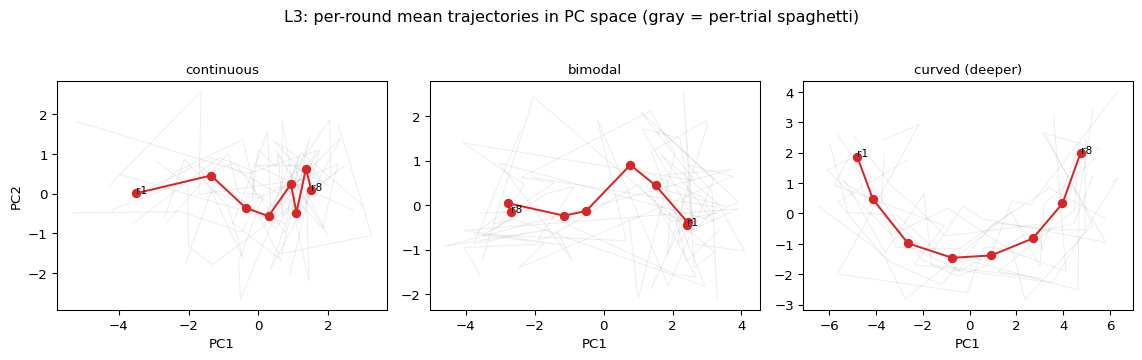

In [5]:
def make_curved():
    X = np.zeros((N_TRIALS, N_TURNS, D))
    d2 = rng.normal(size=D); d2 -= (d2 @ drift_dir) * drift_dir; d2 /= np.linalg.norm(d2)
    theta = np.linspace(0, np.pi * 0.8, N_TURNS)       # arc in a 2-plane
    for i in range(N_TRIALS):
        mag = 5.0 * np.c_[np.cos(theta), np.sin(theta)] @ np.vstack([drift_dir, d2])
        X[i] = base + mag + rng.normal(size=(N_TURNS, D))
    return X

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=False)
for ax, (k, X) in zip(axes, {**worlds, "curved (deeper)": make_curved()}.items()):
    pca = PCA(n_components=2).fit(X.mean(0))
    for i in range(0, N_TRIALS, 6):                    # spaghetti behind the mean
        t = pca.transform(X[i]); ax.plot(t[:, 0], t[:, 1], alpha=0.15, lw=0.7, color="gray")
    m = pca.transform(X.mean(0))
    ax.plot(m[:, 0], m[:, 1], "o-", color="tab:red")
    for t in (0, 7): ax.annotate(f"r{t+1}", m[t], fontsize=8)
    ax.set_title(k, fontsize=10); ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.suptitle("L3: per-round mean trajectories in PC space (gray = per-trial spaghetti)", y=1.03)
plt.tight_layout(); plt.show()


### 2D. L5 — steering & directional ablation (sketch only; needs the model)

Not runnable here; the recipe, so it's decided before we touch hooks
(nnsight 0.7, per `INTERP-METHODS.md` §3):

```python
# steering: add the L2 direction mid-conversation, generation unchanged otherwise
with model.generate(prompt, max_new_tokens=200) as gen:
    for layer in target_layers:
        model.model.layers[layer].output[0][:] += alpha * drift_dir_t
# directional ablation (refusal recipe): project the direction OUT of every layer
        h = model.model.layers[layer].output[0]
        model.model.layers[layer].output[0][:] = h - (h @ d)[..., None] * d
```

**Baselines mandated by spec §7.5:** random direction of equal norm, and the
off-the-shelf sycophancy persona vector. AxBench caveat pre-registered: steering
is the *causal test*, not a claim that steering is the best control knob —
prompting beats it for control, and that's fine, control isn't our claim.


## 3. Thought Anchors: is it our area? — yes, and it brought a neighbor

**Verdict: in scope, and strategically so.** [Thought Anchors: Which LLM
Reasoning Steps Matter?](https://arxiv.org/abs/2506.19143) (Bogdan, Macar,
**Nanda**, Conmy — NeurIPS 2025) is a *MATS-stream paper from Neel's own team*.
Three methods, all at the **sentence** level of CoT traces:

1. **Black-box counterfactual resampling** — resample a sentence ~100×, keep
   semantically different replacements, roll the trace forward, measure the
   shift in the final-answer distribution. Sentences with outsized influence =
   *anchors* (usually planning/uncertainty-management sentences, not computation).
2. **Receiver heads** — attention heads that consistently read from anchor sentences.
3. **Attention suppression** — causal check by masking a sentence's outgoing attention.

**The adaptation for us is turn-level, and it's black-box**: which *counterparty
turn* anchors the stance collapse? Resample turn t (or swap it across persona
scripts), roll the conversation forward k times, measure the shift in
`gave_in` probability and in the probe-projection trajectory. Our fixed-script
personas make this cleaner than free CoT: the "resampled" turn can be a
*controlled* edit. Cost is rollouts (~k×remaining-turns per probe point), i.e.
a vLLM batch job, not a hooks job. → Roadmap **R2**, not this week.

**⚠ New near-neighbor found during verification (novelty-threat log):**
[Sycophantic Anchors](https://arxiv.org/abs/2601.21183) (Duszenko, Jan 2026)
already combines exactly these two ingredients — Thought-Anchors-style
counterfactual rollouts + linear probes — for *user-agreement commitment* in
reasoning models (4 models, 200k rollouts; probes detect sycophantic anchors at
74–85% balanced acc., regressors hit R² ≈ 0.74 on commitment strength; sycophancy
leaves a *stronger* mechanistic footprint than correct reasoning). Overlap: probes
find commitment-to-agreement states. Our daylight: **multi-turn dialogue** drift
(not within-one-trace CoT), the **self-report/faithfulness linkage**, outcome
probes *ahead of the event*, and the **cross-model biology** frame. Action:
add to `refs/deepdive-interp.md` novelty-threat ranking; cite as validation that
the L1 recipe works on exactly this kind of state.

Below, the resampling estimator as a 20-line toy, because the estimator — not
the transformer — is the thing to learn: a 1-D stochastic "stance" process
where one scripted turn is a real anchor and one is a placebo.


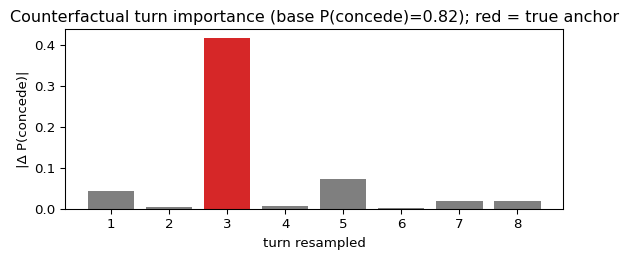

Reading: the estimator recovers the planted anchor at turn 3. On real data this is rollouts through the harness, no hooks — roadmap R2.


In [6]:
# Toy: stance_t+1 = stance_t + push[t] * susceptibility + noise; concede if stance < -2.
# Turn 3 carries a big push (true anchor), turn 5 none (placebo). Counterfactual
# importance of turn t = | P(concede | resampled push_t) - P(concede | script) |.
push = np.array([0.0, -0.3, -1.4, -0.3, 0.0, -0.3, -0.3, -0.3])   # the "script"

def p_concede(push_vec, n=4000):
    s = np.zeros(n)
    conceded = np.zeros(n, bool)
    for t in range(N_TURNS):
        s += push_vec[t] * rng.uniform(0.5, 1.5, n) + rng.normal(0, 0.4, n)
        conceded |= s < -2
    return conceded.mean()

base_p = p_concede(push)
imp = []
for t in range(N_TURNS):                     # resample turn t's push from the script's pool
    alt = push.copy()
    resampled = [p_concede(np.r_[alt[:t], p, alt[t+1:]]) for p in rng.choice(push, 12)]
    imp.append(abs(np.mean(resampled) - base_p))

fig, ax = plt.subplots(figsize=(6, 2.8))
ax.bar(np.arange(1, 9), imp, color=["tab:red" if t == 2 else "tab:gray" for t in range(8)])
ax.set_xlabel("turn resampled"); ax.set_ylabel("|Δ P(concede)|")
ax.set_title(f"Counterfactual turn importance (base P(concede)={base_p:.2f}); red = true anchor")
plt.tight_layout(); plt.show()
assert np.argmax(imp) == 2, "the pushback turn should dominate"
print("Reading: the estimator recovers the planted anchor at turn 3. On real data this "
      "is rollouts through the harness, no hooks — roadmap R2.")


## 4. "Ensemble methods" — where ensembling actually lives in interp

There is no proven "ensemble interp method" family to adopt in 2026. Where
ensembling legitimately appears:

- **Probe stability across seeds/folds** — the direction, not just the accuracy,
  must replicate; report the cosine spread (demo below). This is hygiene for L1/L2.
- **Ensembling weak probes** (bagging per-layer probes) buys accuracy but costs
  the single-direction *interpretation* — for us the direction IS the object, so
  averaging directions (then renormalizing) is acceptable; ensembling classifiers is not.
- **Cross-model replication** — our six-model design is already the strongest
  "ensemble" claim in the study; nothing to add.

So: ensembles enter the paper as a robustness *reporting practice*, one line per
probe result, never as a rung.


In [7]:
X = worlds["continuous"]
dirs = []
for seed in range(8):                        # refit the L1 probe on bootstrap halves
    idx = np.random.default_rng(seed).choice(N_TRIALS, N_TRIALS // 2, replace=False)
    clf = LogisticRegression(max_iter=2000).fit(
        np.vstack([X[idx, 0], X[idx, 7]]), np.r_[np.zeros(len(idx)), np.ones(len(idx))])
    w = clf.coef_.ravel(); dirs.append(w / np.linalg.norm(w))
cos = np.array(dirs) @ np.array(dirs).T
print(f"probe-direction stability: mean off-diagonal cosine = "
      f"{cos[~np.eye(8, dtype=bool)].mean():.3f}  (report this next to every L1 number)")


probe-direction stability: mean off-diagonal cosine = 0.870  (report this next to every L1 number)


## 5. Roadmap — proven on the path, experimental behind numbered gates

**Critical path (this week, all proven, = the ladder):**

| Step | What | Gate |
|---|---|---|
| P0 | **Replay-hooked activation caching** (`resid[trial, turn, layer, d]`, end-of-turn token only, per SPRINT-PLAN "activation pipeline") — *does not exist yet, prerequisite for everything* | — |
| P1 | L1 probes (classify + **regression**) + shuffled/random controls + stability cosine (§4) | P0 |
| P2 | L2 diff-in-means vs probe, per-layer agreement, PC1 dominance | P1 |
| P3 | L3 trajectory figure (spaghetti + mean, per §2C) | P2 |
| P4 | L5 steering + directional ablation with both baselines | P2; the causal rung |

**Experimental roadmap (post-L5 / v2 / blog-post material — each item enters
only through its gate, per spec §5 "every piece of complexity needs a reason"):**

- **R1 — VARX across turns (the MVAR import).** Per
  `refs/mvar-dynamics-and-methods-map.md` §3: VAR(1)+exogenous script drive on
  ≤6-d factor projections; group-lasso optional at this scale. *Gate:* L1–L3
  done early AND the three baselines ready (own-past-only, shuffled-turn,
  read-the-self-reports). ~1 afternoon on the P0 cache, sklearn only.
- **R2 — Turn-level counterfactual resampling (Thought Anchors adapted, §3).**
  Black-box, harness-only. *Gate:* behavioral claim that a specific turn
  anchors collapse becomes load-bearing; budget = one overnight vLLM batch.
- **R3 — Receiver-head analysis across the anchor turn** (Thought Anchors
  method 2). *Gate:* R2 finds a stable anchor turn. Needs attention hooks.
- **R4 — Neural Granger (cMLP, arXiv 1802.05842)** *only if* R1's linear VAR
  shows a large nonlinearity gap (same L4 pattern).
- **R5 — SAE decomposition of the drift direction** (L6, interpret-only, check
  reconstruction on our transcripts first).

Not on any list: attribution graphs/transcoders (no coverage for our models),
within-pass MVAR (killed by the analogy audit — patching dominates).


## 6. Decision: the first method is the **L1 linear probe**, and today's step is P0

**Chosen: linear probing (classify + regression) on cached end-of-turn
residuals**, with its §2A controls and §4 stability report. Why this and not
something newer:

1. It is the **2026 workhorse** — AxBench-validated for detection, and
   Sycophantic Anchors (Jan 2026) just demonstrated this exact recipe works on
   commitment-to-agreement states, the closest published relative of our target.
2. **Everything downstream reuses its output**: L2 compares against its
   direction, L3 plots its space, L5 steers along it, R1's state vector is
   projections onto it. No other first method feeds the whole ladder.
3. **Upskilling-per-hour is highest**: caching + probing touches hooks, the
   replay pipeline, sklearn discipline, and the controls habit — the full
   ARENA-1.x skill set — without any fragile new library.
4. It matches the spec's simplicity criterion; the notebook's §2A reading
   (continuous vs bimodal) means even a "boring" result is a finding.

**Immediate next actions (block 2):**
1. P0 — write `production/driftlab/` caching module (raw HF hooks, end-of-turn
   token, all layers) + unit test on a 2-layer toy model; replay ONE model's
   harness-v1 transcripts (start Qwen3.5-9B) → `resid[trial, turn, layer, d]` on disk.
2. Before any probe number is trusted: the **`inspect view` transcript pass**
   on harness-v1 caches (open item from the Neel-lens review, spec §7.1).
3. Then §2A on real data, per layer, exactly as written above.
